# Sub-basin overlap demo

This notebook shows how to identify sub-basins that fall partially or entirely within a command area mask. It loads the rasters, aligns their grids, tabulates which basins overlap the mask, and visualizes the selected basins.

## Requirements
- `rioxarray` (and `rasterio` under the hood)
- `geopandas`
- `shapely`
- `matplotlib`
- `pandas`

Install any missing packages in your environment before running the notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio.features import shapes, rasterize
from shapely.geometry import shape, box
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [2]:
# Update these paths if your directory layout is different
DATA_DIR = Path("population_data")
SUBBASIN_PATH = DATA_DIR / "Chamoli_fullbasin_flowline" /  "WaterShed.tif"
COMMAND_MASK_PATH = DATA_DIR / "combined_command_area_mask_EPSG4326_90m.tif"

SUBBASIN_PATH, COMMAND_MASK_PATH

(PosixPath('population_data/Chamoli_fullbasin_flowline/WaterShed.tif'),
 PosixPath('population_data/combined_command_area_mask_EPSG4326_90m.tif'))

## Load and align rasters
`rioxarray` automatically tracks georeferencing so we can reproject the mask to match the sub-basin raster. The mask values are assumed to be 1 for in-mask pixels and 0 (or nodata) elsewhere.

In [3]:
subbasins = rxr.open_rasterio(SUBBASIN_PATH, masked=True).squeeze("band")
command_mask = rxr.open_rasterio(COMMAND_MASK_PATH, masked=True).squeeze("band")
print(f"Sub-basin CRS: {subbasins.rio.crs}")
print(f"Sub-basin resolution: {subbasins.rio.resolution()}")

print(f"Command mask CRS: {command_mask.rio.crs}")
print(f"Command mask resolution: {command_mask.rio.resolution()}")

# Align command mask grid to sub-basin raster to make pixel-wise comparisons valid
mask_aligned = command_mask.rio.reproject_match(subbasins)

subbasins, mask_aligned
BASIN_NODATA_VALUE = 65535


Sub-basin CRS: EPSG:4326
Sub-basin resolution: (0.0008333333333333336, -0.0008333333333333336)
Command mask CRS: EPSG:4326
Command mask resolution: (0.000833332760989011, -0.0008333327969102032)


## Identify partial vs entire overlap
The code below compares every sub-basin ID with the aligned mask. A basin is
- **`entirely_in_mask`** if every valid pixel for that basin intersects the mask.
- **`partially_in_mask`** if at least one pixel intersects the mask but not all of them.

The resulting dataframe also includes the fraction of basin pixels that fall within the mask, which can be used later for filtering by coverage threshold.

In [4]:
sub_data = subbasins.data
mask_data = mask_aligned.data

# Build a mask for valid sub-basin pixels (exclude nodata/zero background)
valid = (~np.isnan(sub_data)) & (sub_data > 0)
valid &= sub_data != BASIN_NODATA_VALUE

sub_ids = sub_data[valid].astype(int)
mask_hits = np.where(np.isnan(mask_data[valid]), 0, mask_data[valid] > 0)

coverage = (
    pd.DataFrame({"basin_id": sub_ids, "in_mask": mask_hits})
    .groupby("basin_id")
    .agg(total_pixels=("in_mask", "count"), pixels_in_mask=("in_mask", "sum"))
)
coverage["coverage_fraction"] = coverage["pixels_in_mask"] / coverage["total_pixels"]
coverage["status"] = np.select(
    [coverage["pixels_in_mask"] == 0,
     coverage["pixels_in_mask"] == coverage["total_pixels"]],
    ["outside", "entire"],
    default="partial",
)

coverage.sort_values("coverage_fraction", ascending=False).head()


,total_pixels,pixels_in_mask,coverage_fraction,status
basin_id,,,,
5397,31,31,1.0,entire
9635,561,561,1.0,entire
5175,501,501,1.0,entire
9634,479,479,1.0,entire
5154,86,86,1.0,entire


## Select basin IDs
We can now grab the IDs for basins that are partial or entire, depending on the analysis need. Here we keep both categories (anything except `outside`).

In [5]:
selected = coverage[coverage["status"].isin(["partial", "entire"]) ]
selected_ids = selected.index.to_list()
print(f"Selected basins: {len(selected_ids)} total")
selected.head()

Selected basins: 2039 total


,total_pixels,pixels_in_mask,coverage_fraction,status
basin_id,,,,
147,8137,2031,0.249601,partial
800,5341,1612,0.301816,partial
802,3859,159,0.041202,partial
819,4844,778,0.160611,partial
825,5741,400,0.069674,partial


## Convert selected basins to polygons
`rasterio.features.shapes` vectorizes contiguous pixel regions. We keep only shapes whose value corresponds to the selected basin IDs and store the overlap status for plotting.

In [6]:
raster_arr = subbasins.data
transform = subbasins.rio.transform()

valid_mask = (~np.isnan(raster_arr)) & (raster_arr > 0)
valid_mask &= raster_arr != BASIN_NODATA_VALUE
selected_mask = valid_mask & np.isin(raster_arr, selected_ids)

geoms = []
status_lookup = selected["status"].to_dict()

for geom, basin_val in shapes(raster_arr, mask=selected_mask, transform=transform):
    basin_val = int(basin_val)
    if basin_val in status_lookup:
        geoms.append({
            "geometry": shape(geom),
            "basin_id": basin_val,
            "status": status_lookup[basin_val]
        })

selected_gdf = gpd.GeoDataFrame(geoms, crs=subbasins.rio.crs)
selected_gdf.head()


,geometry,basin_id,status
0,"POLYGON ((79.61458 30.65125, 79.61458 30.65042...",1354,partial
1,"POLYGON ((79.56375 30.59958, 79.56375 30.59875...",1363,partial
2,"POLYGON ((79.47208 30.63292, 79.47208 30.63208...",1364,partial
3,"POLYGON ((79.50542 30.53125, 79.50542 30.53042...",1386,entire
4,"POLYGON ((79.50292 30.52875, 79.50292 30.52708...",1386,entire


## Visualize overlap
The plot below overlays the command area mask raster with the vectorized basins. Basins entirely within the mask are drawn in one color and partially overlapping basins in another.

fig, ax = plt.subplots(figsize=(10, 10))

selected_gdf.plot(
    ax=ax,
    column="status",
    cmap="Set1",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.4, add_colorbar=False)

ax.set_title("Basins overlapping the command area mask")
ax.set_axis_off()
plt.show()

## Select basins using plume path and canal network
To compare alternative selection methods, we load the plume path shapefile and canal raster, bring them into the sub-basin projection, and flag any basins intersected by either dataset.

In [7]:
PLUME_PATH = DATA_DIR / "plume path on river network_EPSG4326_30m.shp"
CANAL_RASTER_PATH = DATA_DIR / "canal_raster_30m.tif"

plume_gdf = gpd.read_file(PLUME_PATH)
print(f"Plume path CRS before reprojection: {plume_gdf.crs}")
plume_gdf = plume_gdf.to_crs(subbasins.rio.crs)
print(f"Plume path CRS after reprojection: {plume_gdf.crs}")

canal_raster = rxr.open_rasterio(CANAL_RASTER_PATH, masked=True).squeeze("band")
print(f"Canal raster CRS before reprojection: {canal_raster.rio.crs}")
canal_aligned = canal_raster.rio.reproject_match(subbasins)
print(f"Canal raster CRS after reprojection: {canal_aligned.rio.crs}")

Plume path CRS before reprojection: EPSG:4326
Plume path CRS after reprojection: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Canal raster CRS before reprojection: PROJCS["WGS_1984_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.4729444],PARAMETER["standard_parallel_2",35.17280555],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9

In [8]:
sub_array = subbasins.data
valid_pixels = (~np.isnan(sub_array)) & (sub_array > 0) & (sub_array != BASIN_NODATA_VALUE)

plume_shapes = [(geom, 1) for geom in plume_gdf.geometry if not geom.is_empty]
plume_mask = rasterize(
    plume_shapes,
    out_shape=subbasins.shape,
    transform=subbasins.rio.transform(),
    fill=0,
    dtype="uint8"
)

plume_basin_ids = np.unique(sub_array[(plume_mask > 0) & valid_pixels])
plume_basin_ids = plume_basin_ids[~np.isnan(plume_basin_ids)].astype(int)
print(f"Basins intersecting plume path: {len(plume_basin_ids)}")


Basins intersecting plume path: 228


In [9]:
canal_mask = (~np.isnan(canal_aligned.data)) & (canal_aligned.data > 0)
canal_basin_ids = np.unique(sub_array[canal_mask & valid_pixels])
canal_basin_ids = canal_basin_ids[~np.isnan(canal_basin_ids)].astype(int)
print(f"Basins intersecting canal raster: {len(canal_basin_ids)}")

Basins intersecting canal raster: 1537


In [10]:
plume_set = set(plume_basin_ids.tolist())
canal_set = set(canal_basin_ids.tolist())

comparison = pd.DataFrame({
    "basin_id": sorted(plume_set | canal_set)
})
comparison["from_plume"] = comparison["basin_id"].isin(plume_set)
comparison["from_canal"] = comparison["basin_id"].isin(canal_set)
comparison["selection_match"] = np.where(
    comparison["from_plume"] == comparison["from_canal"],
    "same",
    "different"
)

only_plume = sorted(plume_set - canal_set)
only_canal = sorted(canal_set - plume_set)

print(f"Basins common to both: {len(plume_set & canal_set)}")
print(f"Only plume: {len(only_plume)} | Only canal: {len(only_canal)}")
comparison.head()

Basins common to both: 42
Only plume: 186 | Only canal: 1495


,basin_id,from_plume,from_canal,selection_match
0,147,False,True,different
1,833,True,False,different
2,837,True,False,different
3,842,True,False,different
4,843,True,False,different


### Visualize basins selected from plume/canal inputs
This map highlights the basins triggered by the plume path and canal datasets after reprojection to the sub-basin grid.

In [11]:
def basins_lookup_to_gdf(id_lookup, label_field="selection"):
    with rasterio.open(SUBBASIN_PATH) as src:
        raster_arr = src.read(1)
        transform = src.transform

    mask_arr = np.isin(raster_arr, list(id_lookup.keys()))
    geoms = []
    for geom, basin_val in shapes(raster_arr, mask=mask_arr, transform=transform):
        basin_val = int(basin_val)
        label = id_lookup.get(basin_val)
        if label is None:
            continue
        geoms.append({
            "geometry": shape(geom),
            "basin_id": basin_val,
            label_field: label,
        })
    return gpd.GeoDataFrame(geoms, crs=subbasins.rio.crs)

plume_canal_lookup = {}
for basin_id in sorted(plume_set | canal_set):
    if basin_id in plume_set and basin_id in canal_set:
        status = "plume+canal"
    elif basin_id in plume_set:
        status = "plume_only"
    else:
        status = "canal_only"
    plume_canal_lookup[basin_id] = status

plume_canal_gdf = basins_lookup_to_gdf(plume_canal_lookup)
plume_canal_gdf.head()

,geometry,basin_id,selection
0,"POLYGON ((79.53542 30.61208, 79.53542 30.61125...",1376,plume_only
1,"POLYGON ((79.67792 30.60708, 79.67792 30.60625...",1372,plume_only
2,"POLYGON ((79.52458 30.55375, 79.52458 30.55292...",1377,plume_only
3,"POLYGON ((79.63708 30.49542, 79.63708 30.49375...",1393,plume_only
4,"POLYGON ((79.59875 30.56625, 79.59875 30.56542...",1382,plume_only


fig, ax = plt.subplots(figsize=(10, 10))
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.3, add_colorbar=False)

if plume_canal_gdf.empty:
    ax.set_title("No basins selected from plume/canal inputs")
else:
    plume_canal_gdf.plot(
        ax=ax,
        column="selection",
        cmap="Accent",
        edgecolor="black",
        linewidth=0.6,
        legend=True,
        alpha=0.7,
    )
    ax.set_title("Basins selected from plume/canal inputs")

ax.set_axis_off()
plt.show()

### Compare selection methods
Overlap the plume/canal-based basins with the mask-selected basins from earlier to see where they agree or diverge.

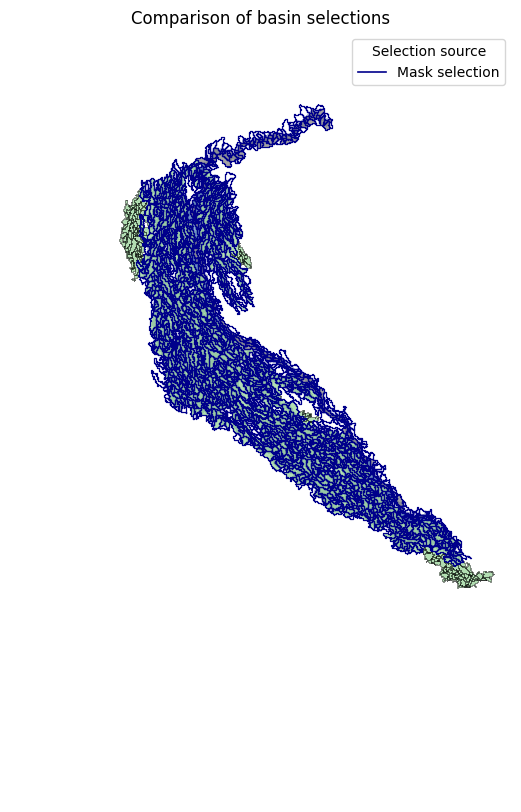

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
mask_aligned.plot(ax=ax, cmap="Blues", alpha=0.25, add_colorbar=False)

if not plume_canal_gdf.empty:
    plume_canal_gdf.plot(
        ax=ax,
        column="selection",
        cmap="Accent",
        alpha=0.6,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
    )

selected_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#00008B",
    linewidth=0.9,
)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="#00008B", linewidth=1.2, label="Mask selection"))
ax.legend(handles=handles, title="Selection source")
ax.set_title("Comparison of basin selections")
ax.set_axis_off()
plt.show()


### Choose downstream selection method
Use this cell to pick which basin selection (mask overlap vs plume/canal hits) feeds subsequent analysis. Change `SELECTION_METHOD` to swap later without recomputing upstream steps.

In [13]:
selection_options = {
    "mask": {
        "description": "Command mask overlap",
        "ids": set(selected.index.astype(int)),
        "gdf": selected_gdf,
    },
    "plume_canal": {
        "description": "Plume path or canal network hits",
        "ids": set(plume_set | canal_set),
        "gdf": plume_canal_gdf,
    },
}

SELECTION_METHOD = "plume_canal"  # change to "plume_canal" as needed
active_selection = selection_options[SELECTION_METHOD]
active_selection_ids = active_selection["ids"]
active_selection_gdf = active_selection["gdf"]
print(f"Using {SELECTION_METHOD} selection: {active_selection['description']}")
print(f"Total basins selected: {len(active_selection_ids)}")


Using plume_canal selection: Plume path or canal network hits
Total basins selected: 1723


### Match plume observation points to selected basins
Sample every plume observation (river and canal) to record the sub-basin ID they fall inside and keep those that intersect the active selection. Canal points remain available for later validation.

In [14]:
PLUME_POINTS_PATH = DATA_DIR / "plume observation points.csv"
plume_points = (
    pd.read_csv(PLUME_POINTS_PATH)
    # .query("location_type != 'canal'")
    .sort_values("event_date")
    .reset_index(drop=True)
)
print(f"Loaded {len(plume_points)} plume observation points")

plume_points_gdf = gpd.GeoDataFrame(
    plume_points,
    geometry=gpd.points_from_xy(plume_points.longitude, plume_points.latitude),
    crs="EPSG:4326",
)
plume_points_proj = plume_points_gdf.to_crs(subbasins.rio.crs)

with rasterio.open(SUBBASIN_PATH) as src:
    coords = [(geom.x, geom.y) for geom in plume_points_proj.geometry]
    sampled = list(src.sample(coords))
basin_values = np.array([vals[0] if vals else np.nan for vals in sampled])

valid_ids = (~np.isnan(basin_values)) & (basin_values != BASIN_NODATA_VALUE)
subbasin_ids = pd.Series(np.where(valid_ids, basin_values, np.nan)).astype("Int64")
plume_points_proj["subbasin_id"] = subbasin_ids

points_in_selection = plume_points_proj[
    plume_points_proj["subbasin_id"].isin(active_selection_ids)
].copy()

print(f"Points intersecting active selection ({SELECTION_METHOD}): {len(points_in_selection)}")
points_in_selection.head()


Loaded 12 plume observation points
Points intersecting active selection (plume_canal): 12


,fid,event_date,event turbidity (NDTI),pre_event_date,post_event_date,location_type,notes,latitude,longitude,date of water turning clear for the first time after the event,note,geometry,subbasin_id
0,1,08/02/2021,NaN,07/02/2021,11/02/2021,dam,NaN,30.25279,78.86828,14/10/2021,stayed high turbility during the monsoon seas...,POINT (78.86828 30.25279),863
1,2,10/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,29.98287,78.20111,26/03/2021,turbidity went down due to the upstream dam co...,POINT (78.20111 29.98287),1046
2,10,11/02/2021,NaN,10/02/2021,14/02/2021,canal,post scene images cloudy could introduce errors,29.55862,77.88201,15/10/2021,stayed high turbility during the monsoon seas...,POINT (77.88201 29.55862),2453
3,3,14/02/2021,NaN,08/02/2021,15/02/2021,dam,NaN,28.22989,78.37665,20/03/2021,NaN,POINT (78.37665 28.22989),3246
4,11,14/02/2021,NaN,10/02/2021,15/02/2021,canal,NaN,28.23815,77.92917,01/11/2021,stayed high turbility during the monsoon seas...,POINT (77.92917 28.23815),3233


### Match river plume points to nearest flowlines
Use river-only plume points to find the closest ordered river segment and 
retrieve its `from_node` / `to_node` IDs. These node IDs are then used 
to derive range boundaries between successive plume observations.


In [19]:
FLOWLINE_PATH = DATA_DIR / "COP90_flowlines" / "RiverNet_Order.shp"
flowlines = gpd.read_file(FLOWLINE_PATH)
print(f"Flowlines CRS before reprojection: {flowlines.crs}")
flowlines = flowlines.to_crs(subbasins.rio.crs)
print(f"Flowlines CRS after reprojection: {flowlines.crs}")

required_cols = {"from_node", "to_node"}
missing = required_cols - set(flowlines.columns)
if missing:
    raise ValueError(f"Missing required flowline columns: {missing}")

# Keep only segments that intersect the active selection area
flowlines_active = flowlines
if not active_selection_gdf.empty:
    bounds = box(*active_selection_gdf.total_bounds)
    flowlines_active = flowlines_active[flowlines_active.intersects(bounds)]
    flowlines_active = flowlines_active[flowlines_active.intersects(active_selection_gdf.unary_union)]
print(f"Flowlines in active selection: {len(flowlines_active)}")

river_points = plume_points_proj[plume_points_proj["location_type"].str.lower() != "canal"].copy()
river_points = river_points.dropna(subset=["event_date"])
river_points = river_points.sort_values("event_date").reset_index(drop=True)

# Nearest flowline for each river plume point
river_points_flow = gpd.sjoin_nearest(
    river_points,
    flowlines_active[["from_node", "to_node", "geometry"]],
    how="left",
    distance_col="flowline_dist",
)

NODE_FIELD = "from_node"  # change to "from_node" if that better matches flow direction
river_points_flow["node_id"] = river_points_flow[NODE_FIELD].astype("Int64")
river_points_flow[["event_date", "location_type", "node_id", "from_node", "to_node", "flowline_dist"]]


Flowlines CRS before reprojection: EPSG:4326
Flowlines CRS after reprojection: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


/tmp/ipykernel_3530047/1803593758.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  flowlines_active = flowlines_active[flowlines_active.intersects(active_selection_gdf.unary_union)]


Flowlines in active selection: 3968


/users/qchen7/.conda/envs/lsdenv/lib/python3.11/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,event_date,location_type,node_id,from_node,to_node,flowline_dist
0,08/02/2021,dam,1242,1242,1229,0.002600
1,10/02/2021,dam,1598,1598,1619,0.002466
2,14/02/2021,dam,5000,5000,5362,0.003447
3,16/02/2021,braided river,6259,6259,6284,0.007142
4,17/02/2021,braided river,6794,6794,6824,0.008023
5,18/02/2021,braided river,7393,7393,7574,0.011038
6,19/02/2021,braided river,8025,8025,8076,0.010906
7,22/02/2021,dam,9717,9717,9797,0.010030
8,25/02/2021,braided river,10154,10154,10396,0.000353


### Derive node ranges between plume observations
Build ordered node ID ranges from the river plume points. These ranges 
replace the earlier basin-ID slicing logic.


In [20]:
river_points_flow = river_points_flow.dropna(subset=["node_id"]).copy()
river_points_flow["node_id"] = river_points_flow["node_id"].astype(int)

node_ranges = []
prev_id = None
prev_date = None
for _, row in river_points_flow.iterrows():
    current_id = row["node_id"]
    current_date = row["event_date"]
    if prev_id is None:
        range_desc = f"<= {current_id}"
        lower_bound = None
    else:
        range_desc = f">= {prev_id} and < {current_id}"
        lower_bound = prev_id
    node_ranges.append({
        "event_date": current_date,
        "node_id": current_id,
        "previous_event_date": prev_date,
        "lower_bound_id": lower_bound,
        "upper_bound_id": current_id,
        "range_condition": range_desc,
    })
    prev_id = current_id
    prev_date = current_date

node_ranges_df = pd.DataFrame(node_ranges)
event_dates = pd.to_datetime(node_ranges_df["event_date"], errors="coerce", dayfirst=True)
node_ranges_df["event_date_label"] = event_dates.dt.strftime("%b %d").str.replace(" 0", " ", regex=False)
prev_dates = pd.to_datetime(node_ranges_df["previous_event_date"], errors="coerce", dayfirst=True)
node_ranges_df["previous_event_date_label"] = prev_dates.dt.strftime("%b %d").str.replace(" 0", " ", regex=False)
node_ranges_df


,event_date,node_id,previous_event_date,lower_bound_id,upper_bound_id,range_condition,event_date_label,previous_event_date_label
0,08/02/2021,1242,None,NaN,1242,<= 1242,Feb 8,NaN
1,10/02/2021,1598,08/02/2021,1242.0,1598,>= 1242 and < 1598,Feb 10,Feb 8
2,14/02/2021,5000,10/02/2021,1598.0,5000,>= 1598 and < 5000,Feb 14,Feb 10
3,16/02/2021,6259,14/02/2021,5000.0,6259,>= 5000 and < 6259,Feb 16,Feb 14
4,17/02/2021,6794,16/02/2021,6259.0,6794,>= 6259 and < 6794,Feb 17,Feb 16
5,18/02/2021,7393,17/02/2021,6794.0,7393,>= 6794 and < 7393,Feb 18,Feb 17
6,19/02/2021,8025,18/02/2021,7393.0,8025,>= 7393 and < 8025,Feb 19,Feb 18
7,22/02/2021,9717,19/02/2021,8025.0,9717,>= 8025 and < 9717,Feb 22,Feb 19
8,25/02/2021,10154,22/02/2021,9717.0,10154,>= 9717 and < 10154,Feb 25,Feb 22


### Map basins affected between plume observations (node ranges)
Select flowlines whose node IDs fall within each derived range, then 
flag basins intersecting those flowlines.


In [ ]:
if node_ranges_df.empty or active_selection_gdf.empty:
    print("No node ranges or active selection available for mapping")
else:
    if "basin_id" not in active_selection_gdf.columns:
        raise ValueError("Active selection GeoDataFrame lacks basin_id column")

    DATE_PALETTE = [
        "#DC050C",  # before 8th February
        "#E8601C",
        "#F6C141",
        "#F7F056",
        "#CAE0AB",
        "#4EB265",
        "#7BAFDE",
        "#1965B0",
        "#882E72",  # 22nd to 25th
    ]
    MARKER_RIVER = "o"
    MARKER_CANAL = "s"
    MARKER_STRUCTURE = "^"  # river with dam/barrage

    def node_in_range(node_id, lower, upper):
        if pd.isna(node_id):
            return False
        if pd.isna(lower):
            return node_id <= upper
        return (node_id >= lower) and (node_id < upper)

    range_polys = []
    range_defs = []
    for order, row in enumerate(node_ranges_df.itertuples()):
        prev_label = row.previous_event_date_label if pd.notna(row.previous_event_date_label) else "start"
        label = f"{prev_label} -> {row.event_date_label}"
        lower = row.lower_bound_id
        upper = row.upper_bound_id
        range_defs.append({"label": label, "lower": lower, "upper": upper})

        fl_mask = flowlines_active[NODE_FIELD].apply(lambda v: node_in_range(v, lower, upper))
        fl_subset = flowlines_active[fl_mask].copy()
        if fl_subset.empty:
            continue

        basins_subset = gpd.sjoin(
            active_selection_gdf,
            fl_subset[["geometry"]],
            predicate="intersects",
            how="inner",
        )
        basins_subset = basins_subset.drop_duplicates(subset=["basin_id"]).copy()
        if basins_subset.empty:
            continue
        basins_subset["range_label"] = label
        basins_subset["range_order"] = order
        range_polys.append(basins_subset)

    if not range_polys:
        print("No basins matched the derived node ranges")
    else:
        range_gdf = gpd.GeoDataFrame(pd.concat(range_polys, ignore_index=True), crs=active_selection_gdf.crs)
        unique_labels = range_gdf["range_label"].unique()
        colors = [DATE_PALETTE[i % len(DATE_PALETTE)] for i in range(len(unique_labels))]

        fig, ax = plt.subplots(figsize=(14, 12))
        mask_aligned.plot(ax=ax, cmap="Greys", alpha=0.2, add_colorbar=False)

        legend_handles = []
        for i, label in enumerate(unique_labels):
            subset = range_gdf[range_gdf["range_label"] == label]
            color = colors[i]
            subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
            legend_handles.append(Patch(facecolor=color, edgecolor="black", label=label))

        def assign_range_label(node_id):
            for rng in range_defs:
                if node_in_range(node_id, rng["lower"], rng["upper"]):
                    return rng["label"]
            return None

        river_points_flow["range_label"] = river_points_flow["node_id"].apply(assign_range_label)

        point_styles = {
            "dam": {"marker": MARKER_STRUCTURE, "color": "black", "label": "Dam plume"},
            "braided river": {"marker": MARKER_RIVER, "color": "black", "label": "Braided river plume"},
            "canal": {"marker": MARKER_CANAL, "color": "black", "label": "Canal plume"},
        }
        point_handles = []
        for loc, style in point_styles.items():
            subset = plume_points_proj[plume_points_proj["location_type"].str.lower() == loc]
            if subset.empty:
                continue
            ax.scatter(
                subset.geometry.x,
                subset.geometry.y,
                s=30,
                c=style["color"],
                marker=style["marker"],
                edgecolors="white",
                linewidths=0.1,
                zorder=5,
            )
            point_handles.append(
                Line2D([0], [0], marker=style["marker"], linestyle="",
                       markerfacecolor=style["color"], markeredgecolor="black",
                       markersize=8, label=style.get("label", loc.title()))
            )

        boundary = box(*mask_aligned.rio.bounds())
        gpd.GeoSeries([boundary], crs=mask_aligned.rio.crs).boundary.plot(
            ax=ax, color="black", linewidth=1.0, linestyle="--"
        )

        ax.set_title("Basins newly affected between plume observations (node ranges)")
        ax.set_xlabel("easting (degree)")
        ax.set_ylabel("northing (degree)")
        ax.set_xlim(76.5, 81)
        ax.set_ylim(25, 31)

        color_legend = ax.legend(
            handles=legend_handles,
            title="Affected basins by date range",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
        )
        ax.add_artist(color_legend)

        ax.legend(
            handles=point_handles,
            title="Plume locations",
            bbox_to_anchor=(1.02, 0.6),
            loc="upper left",
            borderaxespad=0,
        )
        plt.show()


In [ ]:
node_ranges_df

NameError: name 'river_ranges_df' is not defined

### Estimate affected population per plume range
Sum the `world_pop_2021_affected.tif` values inside each basin range to quantify how many people are affected between successive plume observations.

In [ ]:
from rasterio.enums import Resampling

TARGET_CRS = rxr.open_rasterio(CANAL_RASTER_PATH, masked=True).rio.crs
TARGET_RESOLUTION = 90  # meters

POPULATION_PATH = DATA_DIR / "world_pop_2021_affected.tif"
population_raw = rxr.open_rasterio(POPULATION_PATH, masked=True).squeeze("band")
print(f"Population raster CRS: {population_raw.rio.crs}")
print(f"Population raster resolution: {population_raw.rio.resolution()}")

subbasins_target = subbasins.rio.reproject(
    TARGET_CRS,
    resolution=TARGET_RESOLUTION,
    resampling=Resampling.nearest,
)
print(f"Sub-basin raster CRS (target): {subbasins_target.rio.crs}")
print(f"Sub-basin raster resolution (target): {subbasins_target.rio.resolution()}")

population_aligned = population_raw.rio.reproject_match(
    subbasins_target,
    resampling=Resampling.sum,
    nodata=0,
)
print(f"Aligned population raster resolution: {population_aligned.rio.resolution()}")

population_data = population_aligned.data
basin_data = subbasins_target.data
valid_pixels = (~np.isnan(population_data)) & (~np.isnan(basin_data))
pixel_area = abs(population_aligned.rio.resolution()[0] * population_aligned.rio.resolution()[1])

population_df = pd.DataFrame({
    "basin_id": basin_data[valid_pixels].astype(int),
    "population": population_data[valid_pixels],
    "pixel_area": pixel_area,
})
population_by_basin = population_df.groupby("basin_id").sum()
population_by_basin = population_by_basin.rename(columns={"pixel_area": "basin_area_sq_m"})

print(f"Reference total population (aligned): {population_by_basin['population'].sum():,.0f}")

# helper functions on meter-based grid
def population_in_range(lower, upper):
    if pd.isna(lower):
        mask = population_by_basin.index <= upper
    else:
        mask = (population_by_basin.index >= lower) & (population_by_basin.index < upper)
    return population_by_basin.loc[mask, "population"].sum()

def area_in_range(lower, upper):
    if pd.isna(lower):
        mask = population_by_basin.index <= upper
    else:
        mask = (population_by_basin.index >= lower) & (population_by_basin.index < upper)
    return population_by_basin.loc[mask, "basin_area_sq_m"].sum()

range_population = []
for row in node_ranges_df.itertuples():
    affected_pop = population_in_range(row.lower_bound_id, row.upper_bound_id)
    affected_area = area_in_range(row.lower_bound_id, row.upper_bound_id)
    range_population.append({
        "event_date": row.event_date,
        "previous_event_date": row.previous_event_date,
        "range_condition": row.range_condition if "range_condition" in node_ranges_df.columns else None,
        "affected_population": affected_pop,
        "affected_area_sq_m": affected_area,
    })

range_population_df = pd.DataFrame(range_population)
range_population_df["cumulative_population"] = range_population_df["affected_population"].cumsum()
range_population_df["cumulative_area_sq_m"] = range_population_df["affected_area_sq_m"].cumsum()
range_population_df["cumulative_area_sq_km"] = range_population_df["cumulative_area_sq_m"] / 1_000_000
range_population_df

Population raster CRS: EPSG:4326
Population raster resolution: (0.000833332760989011, -0.0008333327969102032)


Sub-basin raster CRS (target): PROJCS["WGS_1984_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.4729444],PARAMETER["standard_parallel_2",35.17280555],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Sub-basin raster resolution (target): (90.0, -90.0)
Aligned population raster resolution: (90.00000000000007, -90.0)
Reference total population (aligned): 43,194,072


,event_date,previous_event_date,range_condition,affected_population,affected_area_sq_m,cumulative_population,cumulative_area_sq_m,cumulative_area_sq_km
0,08/02/2021,None,<= 863,5.649302e+04,2.306516e+10,5.649302e+04,2.306516e+10,23065.1631
1,10/02/2021,08/02/2021,>= 863 and < 1046,3.345105e+05,4.345998e+09,3.910035e+05,2.741116e+10,27411.1614
2,14/02/2021,10/02/2021,>= 1046 and < 3246,1.666029e+07,5.812923e+10,1.705130e+07,8.554039e+10,85540.3902
3,16/02/2021,14/02/2021,>= 3246 and < 5200,4.796704e+06,5.091788e+10,2.184800e+07,1.364583e+11,136458.2700
4,17/02/2021,16/02/2021,>= 5200 and < 6342,9.400382e+06,3.050422e+10,3.124838e+07,1.669625e+11,166962.4893
5,18/02/2021,17/02/2021,>= 6342 and < 6419,4.970171e+05,2.398321e+09,3.174540e+07,1.693608e+11,169360.8102
6,19/02/2021,18/02/2021,>= 6419 and < 6497,3.220063e+05,1.875126e+09,3.206741e+07,1.712359e+11,171235.9359
7,22/02/2021,19/02/2021,>= 6497 and < 6788,3.066054e+06,7.634007e+09,3.513346e+07,1.788699e+11,178869.9429
8,25/02/2021,22/02/2021,>= 6788 and < 6875,3.272141e+06,2.366504e+09,3.840560e+07,1.812364e+11,181236.4470


### Current limitation / debugging note
The final visualization takes basin ranges from plume observations but slices them over the *active* selection (`mask` by default). When a plume’s basin ID lies outside the mask-selected set, `len(subset)` becomes 0 because there are no polygons to color. 

Possible fixes: 1) switch `SELECTION_METHOD` to `"plume_canal"` so the geometry set covers river reaches beyond the command mask, 2) expand the mask selection criteria (e.g., accept partially overlapping basins) so they intersect the plume IDs, or 3) clip the plume ranges against the available `active_selection_ids` before plotting so the code only uses ranges that exist in the current geometry set.

### Next steps
- Join the `coverage` dataframe back to population tables if you need counts per basin.
- Adjust the `coverage_fraction` threshold if you want to focus on basins that are mostly inside the mask but not entirely.
- Export `selected_gdf` as a shapefile or GeoJSON for downstream GIS workflows using `selected_gdf.to_file("selected_basins.geojson", driver="GeoJSON")`.